## Language Distribution Visualization (Before Data Augmentation)

/tmp/ipykernel_2234/1876654152.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='language', order=df['language'].value_counts().index, palette='viridis')


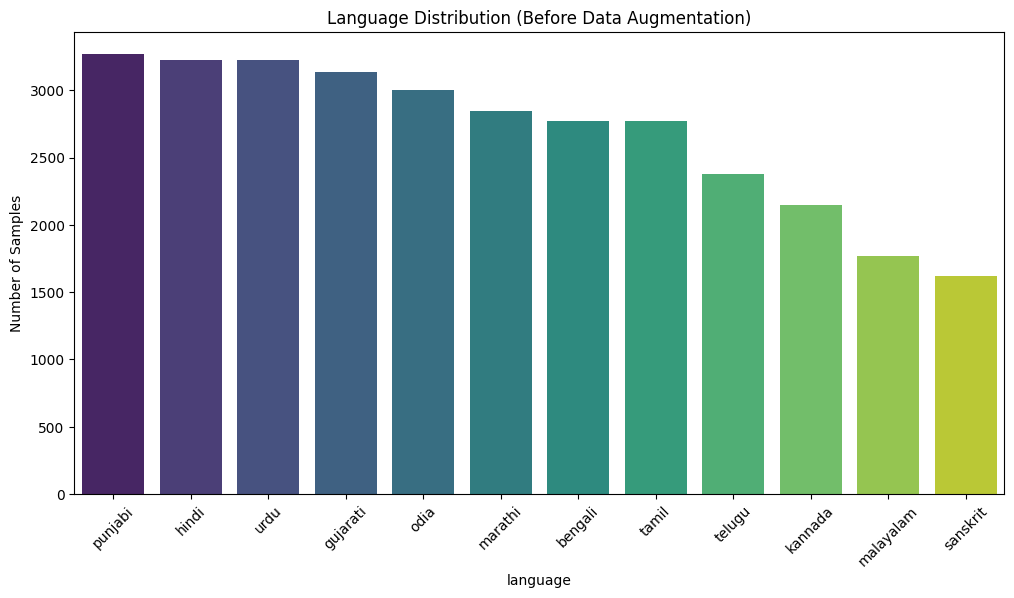

Final Count per Language:
language
punjabi      3270
hindi        3229
urdu         3229
gujarati     3139
odia         3001
marathi      2849
bengali      2772
tamil        2770
telugu       2379
kannada      2150
malayalam    1768
sanskrit     1620
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your final cleaned training CSV
df = pd.read_csv("master_valid_dataset_standardized2.csv")

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='language', order=df['language'].value_counts().index, palette='viridis')
plt.title("Language Distribution (Before Data Augmentation)")
plt.xticks(rotation=45)
plt.ylabel("Number of Samples")
plt.show()

# Print exact numbers for your report
print("Final Count per Language:")
print(df['language'].value_counts())

## Data Augmentation

In [2]:
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
import os
import random
from tqdm import tqdm

# --- 1. CONFIGURATION ---
input_csv = "master_valid_dataset_standardized2.csv" # The output from your previous script
output_csv = "master_valid_augmented.csv"

# --- 2. AUGMENTATION FUNCTIONS ---
def add_white_noise(data, noise_factor=0.005):
    noise = np.random.randn(len(data))
    return data + noise_factor * noise

def shift_pitch(data, sr=16000, n_steps=2):
    return librosa.effects.pitch_shift(data, sr=sr, n_steps=n_steps)

def stretch_time(data, rate=1.1):
    return librosa.effects.time_stretch(data, rate=rate)

# --- 3. THE BALANCING LOGIC ---
df = pd.read_csv(input_csv)
counts = df['language'].value_counts()
max_target = counts.max()  # We will balance every language to this number

print(f"📊 Current Distribution:\n{counts}")
print(f"🎯 Target samples per language: {max_target}")

augmented_rows = []

for lang in counts.index:
    lang_df = df[df['language'] == lang]
    current_count = len(lang_df)
    needed = max_target - current_count
    
    if needed > 0:
        print(f"✨ Augmenting {lang}: Creating {needed} synthetic samples...")
        for i in tqdm(range(needed)):
            # Pick a random original file to transform
            source_row = lang_df.sample(n=1).iloc[0]
            y, sr = librosa.load(source_row['file_path'], sr=16000)
            
            # Apply a random transformation to create "new" data
            choice = random.choice(['noise', 'pitch', 'stretch'])
            if choice == 'noise':
                y_aug = add_white_noise(y, noise_factor=random.uniform(0.001, 0.006))
            elif choice == 'pitch':
                y_aug = shift_pitch(y, sr=sr, n_steps=random.uniform(-1.5, 1.5))
            else:
                y_aug = stretch_time(y, rate=random.uniform(0.9, 1.1))
            
            # Save the new augmented file
            aug_dir = os.path.join(os.path.dirname(source_row['file_path']), "augmented")
            os.makedirs(aug_dir, exist_ok=True)
            new_filename = f"aug_{choice}_{i}_{os.path.basename(source_row['file_path'])}"
            new_path = os.path.join(aug_dir, new_filename)
            
            sf.write(new_path, y_aug, sr)
            
            # Record the new path and ID in our metadata
            new_row = source_row.copy()
            new_row['file_path'] = os.path.abspath(new_path)
            new_row['file_id'] = f"aug_{new_filename}"
            augmented_rows.append(new_row)

# Combine original data with newly created augmented rows
df_final = pd.concat([df, pd.DataFrame(augmented_rows)], ignore_index=True)
df_final.to_csv(output_csv, index=False)
print(f"✅ Balanced dataset saved as: {output_csv}")

📊 Current Distribution:
language
punjabi      3270
hindi        3229
urdu         3229
gujarati     3139
odia         3001
marathi      2849
bengali      2772
tamil        2770
telugu       2379
kannada      2150
malayalam    1768
sanskrit     1620
Name: count, dtype: int64
🎯 Target samples per language: 3270
✨ Augmenting hindi: Creating 41 synthetic samples...


  0%|                                                                                            | 0/41 [00:00<?, ?it/s]/home/zahir/trans_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|███████████████████████████████████████████████████████████████████████████████████| 41/41 [00:03<00:00, 11.48it/s]


✨ Augmenting urdu: Creating 41 synthetic samples...


100%|███████████████████████████████████████████████████████████████████████████████████| 41/41 [00:01<00:00, 40.67it/s]


✨ Augmenting gujarati: Creating 131 synthetic samples...


...

✨ Augmenting malayalam: Creating 1502 synthetic samples...


100%|███████████████████████████████████████████████████████████████████████████████| 1502/1502 [00:57<00:00, 26.31it/s]


✨ Augmenting sanskrit: Creating 1650 synthetic samples...


100%|███████████████████████████████████████████████████████████████████████████████| 1650/1650 [01:08<00:00, 24.16it/s]


✅ Balanced dataset saved as: master_valid_augmented.csv


## Quality Control

In [3]:
import pandas as pd
import librosa
import os
from tqdm import tqdm

def run_quality_control(csv_path):
    print(f"\n🔍 Running Quality Control: {csv_path}")
    df = pd.read_csv(csv_path)
    initial_count = len(df)
    
    valid_indices = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Scanning Audio Quality"):
        file_path = row['file_path']
        
        if os.path.exists(file_path):
            try:
                # Get duration without loading full file (saves time/RAM)
                duration = librosa.get_duration(path=file_path)
                
                # Rule: Keep only files between 0.5 seconds and 30 seconds
                if 0.5 <= duration <= 30.0:
                    valid_indices.append(idx)
            except Exception:
                continue # Skip corrupt files
                
    df_cleaned = df.iloc[valid_indices]
    removed_count = initial_count - len(df_cleaned)
    
    final_output = csv_path.replace(".csv", "_cleaned.csv")
    df_cleaned.to_csv(final_output, index=False)
    
    print(f"✅ QC Finished!")
    print(f"🗑️ Removed {removed_count} files (empty, corrupt, or too short).")
    print(f"📦 Final Ready-to-Train Dataset: {len(df_cleaned)} samples.")
    print(f"📍 Location: {final_output}")

run_quality_control("master_valid_augmented.csv")


🔍 Running Quality Control: master_valid_augmented.csv


Scanning Audio Quality: 100%|███████████████████████████████████████████████████| 39240/39240 [00:18<00:00, 2157.18it/s]


✅ QC Finished!
🗑️ Removed 14 files (empty, corrupt, or too short).
📦 Final Ready-to-Train Dataset: 39226 samples.
📍 Location: master_valid_augmented_cleaned.csv


## Final Distribution Visualization

/tmp/ipykernel_2234/1069099059.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='language', order=df['language'].value_counts().index, palette='viridis')


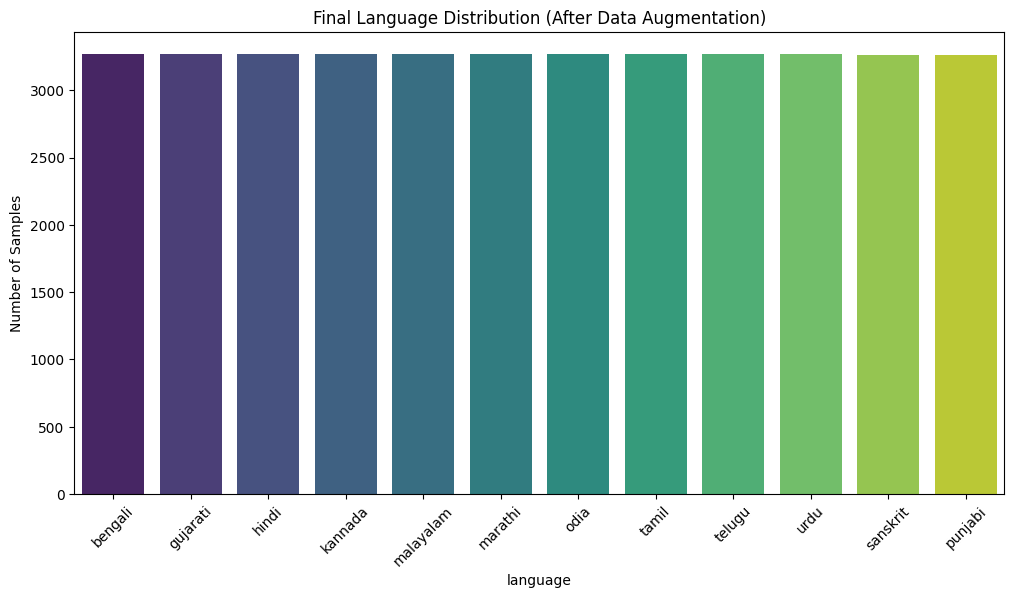

Final Count per Language:
language
bengali      3270
gujarati     3270
hindi        3270
kannada      3270
malayalam    3270
marathi      3270
odia         3270
tamil        3270
telugu       3270
urdu         3270
sanskrit     3265
punjabi      3261
Name: count, dtype: int64


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your final cleaned training CSV
df = pd.read_csv("master_valid_augmented_cleaned.csv")

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='language', order=df['language'].value_counts().index, palette='viridis')
plt.title("Final Language Distribution (After Data Augmentation)")
plt.xticks(rotation=45)
plt.ylabel("Number of Samples")
plt.show()

# Print exact numbers for your report
print("Final Count per Language:")
print(df['language'].value_counts())